# Librairies

In [124]:
# manipulation des données et graphiques
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# garbage collector
import gc

# preprocessing
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# modèles
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier

# pipelines, CV et métriques
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_predict
from sklearn.metrics import roc_auc_score, confusion_matrix, make_scorer
import time

# MLFlow
import mlflow
from mlflow.tracking import MlflowClient
from pathlib import Path
import shutil
import json

# Feature importance
import shap

# data drift
from evidently import Report
from evidently.presets import DataDriftPreset

RANDOM_STATE = 42

In [52]:
# suppress warnings
import warnings
warnings.filterwarnings("ignore")

# Configuration graphique

In [53]:
# Thème global
sns.set_theme(
    style="whitegrid",
    context="notebook",
    palette="deep"
)
COLOR_NO_DEFAULT = "#4C72B0"   # bleu seaborn
COLOR_DEFAULT = "#DD8452"      # orange doux

# Les données

In [54]:
DATA_DIR = Path("./data/raw")

## Application_train.csv

In [55]:
df = pd.read_csv(DATA_DIR / "application_train.csv")
df.shape

(307511, 122)

In [56]:
df.head()


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [57]:
df.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Data columns (total 122 columns):
 #    Column                        Dtype  
---   ------                        -----  
 0    SK_ID_CURR                    int64  
 1    TARGET                        int64  
 2    NAME_CONTRACT_TYPE            object 
 3    CODE_GENDER                   object 
 4    FLAG_OWN_CAR                  object 
 5    FLAG_OWN_REALTY               object 
 6    CNT_CHILDREN                  int64  
 7    AMT_INCOME_TOTAL              float64
 8    AMT_CREDIT                    float64
 9    AMT_ANNUITY                   float64
 10   AMT_GOODS_PRICE               float64
 11   NAME_TYPE_SUITE               object 
 12   NAME_INCOME_TYPE              object 
 13   NAME_EDUCATION_TYPE           object 
 14   NAME_FAMILY_STATUS            object 
 15   NAME_HOUSING_TYPE             object 
 16   REGION_POPULATION_RELATIVE    float64
 17   DAYS_BIRTH                    int64  
 18   DA

In [58]:
df["TARGET"].value_counts(normalize=True)

TARGET
0    0.919271
1    0.080729
Name: proportion, dtype: float64

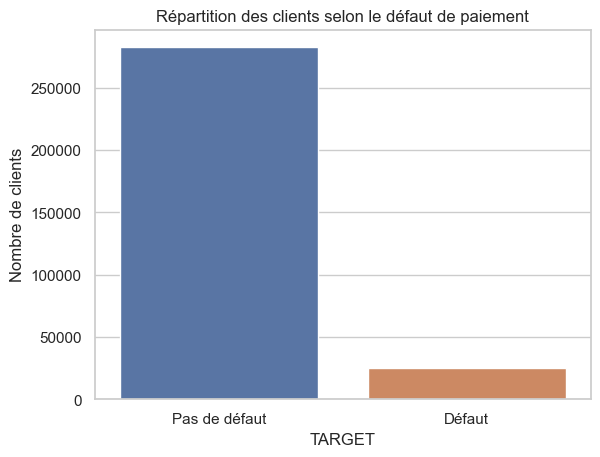

In [59]:
# graphique target
sns.barplot(
    x=df["TARGET"].value_counts().index,
    y=df["TARGET"].value_counts().values,
    palette=[COLOR_NO_DEFAULT, COLOR_DEFAULT]
)
plt.xticks([0, 1], ["Pas de défaut", "Défaut"])
plt.title("Répartition des clients selon le défaut de paiement")
plt.ylabel("Nombre de clients")
plt.show()

In [60]:
df.dtypes.value_counts()

float64    65
int64      41
object     16
Name: count, dtype: int64

### Valeurs manquantes

In [61]:
df.isna().sum()

SK_ID_CURR                        0
TARGET                            0
NAME_CONTRACT_TYPE                0
CODE_GENDER                       0
FLAG_OWN_CAR                      0
                              ...  
AMT_REQ_CREDIT_BUREAU_DAY     41519
AMT_REQ_CREDIT_BUREAU_WEEK    41519
AMT_REQ_CREDIT_BUREAU_MON     41519
AMT_REQ_CREDIT_BUREAU_QRT     41519
AMT_REQ_CREDIT_BUREAU_YEAR    41519
Length: 122, dtype: int64

In [62]:
missing_rate = df.isna().mean().sort_values(ascending=False)
print(missing_rate.shape)
missing_rate.head(15)

(122,)


COMMONAREA_MEDI             0.698723
COMMONAREA_AVG              0.698723
COMMONAREA_MODE             0.698723
NONLIVINGAPARTMENTS_MODE    0.694330
NONLIVINGAPARTMENTS_AVG     0.694330
NONLIVINGAPARTMENTS_MEDI    0.694330
FONDKAPREMONT_MODE          0.683862
LIVINGAPARTMENTS_MODE       0.683550
LIVINGAPARTMENTS_AVG        0.683550
LIVINGAPARTMENTS_MEDI       0.683550
FLOORSMIN_AVG               0.678486
FLOORSMIN_MODE              0.678486
FLOORSMIN_MEDI              0.678486
YEARS_BUILD_MEDI            0.664978
YEARS_BUILD_MODE            0.664978
dtype: float64

In [63]:
missing_rate[missing_rate > 0].shape

(67,)

Un grand nombre de variables présente des valeurs manquantes importantes.
Certaines variables sont très incomplètes et devront être exclues ou traitées
spécifiquement lors de la phase de préparation des données.


Le jeu de données contient un mélange de variables numériques et catégorielles.
Cette hétérogénéité nécessitera un prétraitement spécifique
(imputation, encodage) avant la modélisation.

### AGE

In [64]:
# Âge en années (plus lisible que DAYS_BIRTH)
df["AGE_YEARS"] = -df["DAYS_BIRTH"] / 365

df["AGE_YEARS"].describe()

count    307511.000000
mean         43.936973
std          11.956133
min          20.517808
25%          34.008219
50%          43.150685
75%          53.923288
max          69.120548
Name: AGE_YEARS, dtype: float64

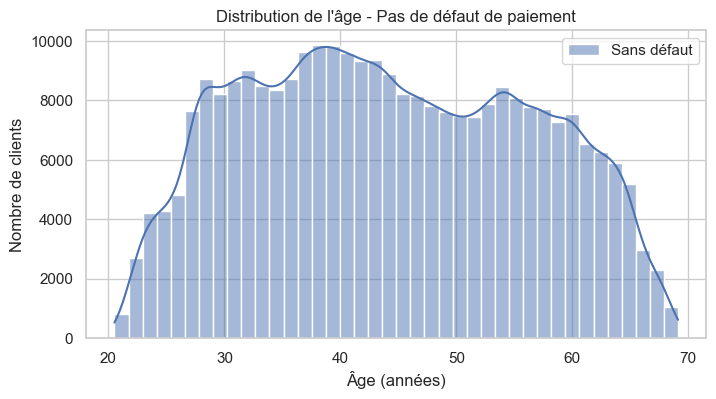

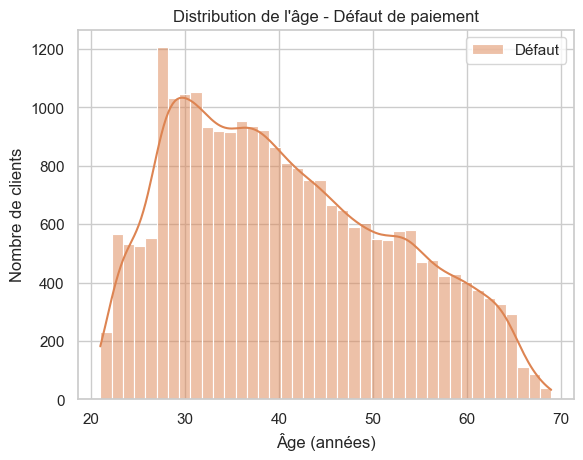

In [65]:
plt.figure(figsize=(8, 4))

sns.histplot(
    df[df["TARGET"] == 0]["AGE_YEARS"],
    bins=40,
    color=COLOR_NO_DEFAULT,
    label="Sans défaut",
    kde=True,
    # alpha=0.6
)
plt.xlabel("Âge (années)")
plt.ylabel("Nombre de clients")
plt.title("Distribution de l'âge - Pas de défaut de paiement")
plt.legend()
plt.show()

sns.histplot(
    df[df["TARGET"] == 1]["AGE_YEARS"],
    bins=40,
    color=COLOR_DEFAULT,
    label="Défaut",
    kde=True,
    # alpha=0.6
)
plt.xlabel("Âge (années)")
plt.ylabel("Nombre de clients")
plt.title("Distribution de l'âge - Défaut de paiement")
plt.legend()

plt.show()


Les clients les plus jeunes présentent une probabilité plus élevée de défaut de paiement.
Cette observation est cohérente avec l’intuition métier :
les profils plus jeunes ont souvent une situation financière moins stable.

In [66]:
age_data = df[['TARGET', 'AGE_YEARS']]
age_data['YEAR_BIN'] = pd.cut(age_data['AGE_YEARS'], bins=np.linspace(20, 70, 11))
age_groups  = age_data.groupby('YEAR_BIN').mean()
age_groups

,TARGET,AGE_YEARS
YEAR_BIN,,
"(20.0, 25.0]",0.123036,23.377522
"(25.0, 30.0]",0.111436,27.822518
"(30.0, 35.0]",0.102814,32.479037
"(35.0, 40.0]",0.089414,37.555913
"(40.0, 45.0]",0.078491,42.459346
"(45.0, 50.0]",0.074171,47.462741
"(50.0, 55.0]",0.066968,52.593136
"(55.0, 60.0]",0.055314,57.491131
"(60.0, 65.0]",0.052737,62.412459


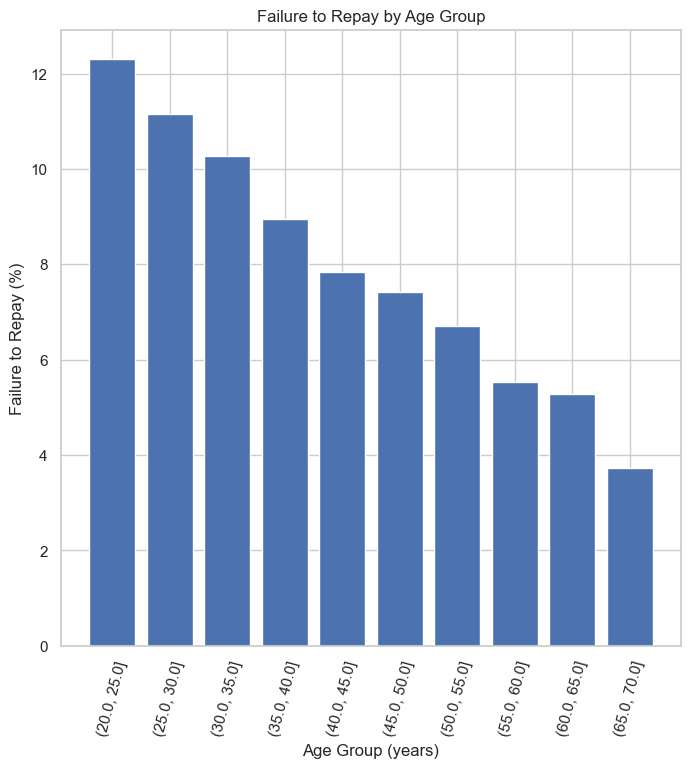

In [67]:
plt.figure(figsize = (8, 8))

# Graph the age bins and the average of the target as a bar plot
plt.bar(age_groups.index.astype(str), 100 * age_groups['TARGET'])

# Plot labeling
plt.xticks(rotation = 75); plt.xlabel('Age Group (years)'); plt.ylabel('Failure to Repay (%)')
plt.title('Failure to Repay by Age Group');

### Revenu annuel

In [68]:
df["AMT_INCOME_TOTAL"].describe()

count    3.075110e+05
mean     1.687979e+05
std      2.371231e+05
min      2.565000e+04
25%      1.125000e+05
50%      1.471500e+05
75%      2.025000e+05
max      1.170000e+08
Name: AMT_INCOME_TOTAL, dtype: float64

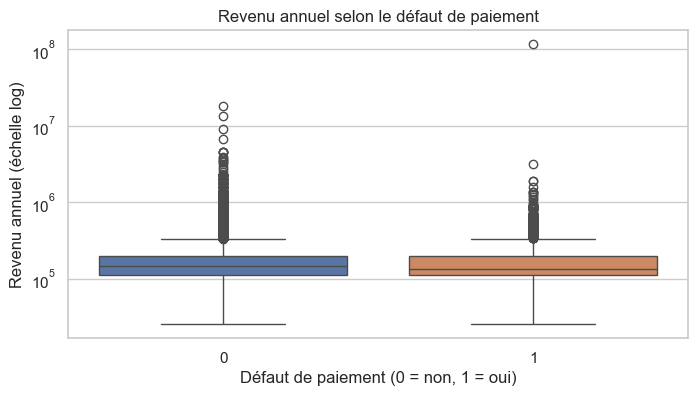

In [69]:
plt.figure(figsize=(8, 4))
sns.boxplot(
    data=df,
    x="TARGET",
    y="AMT_INCOME_TOTAL",
    palette=[COLOR_NO_DEFAULT, COLOR_DEFAULT]
)
plt.yscale("log")
plt.title("Revenu annuel selon le défaut de paiement")
plt.xlabel("Défaut de paiement (0 = non, 1 = oui)")
plt.ylabel("Revenu annuel (échelle log)")
plt.show()


### Charge de crédit

In [70]:
# Ratio simple : annuité / crédit
df["PAYMENT_RATE"] = df["AMT_ANNUITY"] / df["AMT_CREDIT"]

df["PAYMENT_RATE"].describe()

count    307499.000000
mean          0.053695
std           0.022481
min           0.022073
25%           0.036900
50%           0.050000
75%           0.064043
max           0.124430
Name: PAYMENT_RATE, dtype: float64

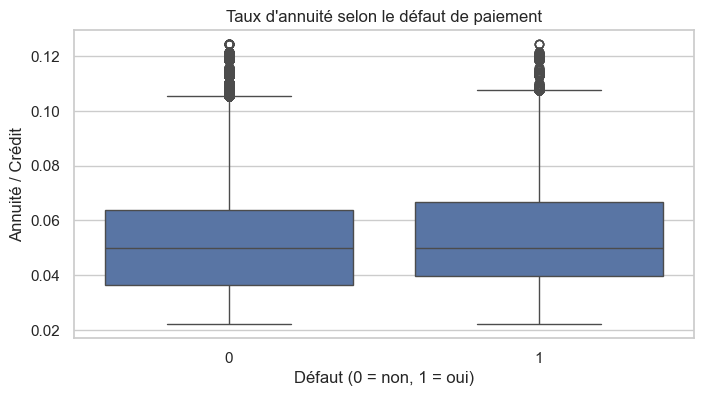

In [71]:
plt.figure(figsize=(8, 4))
sns.boxplot(
    data=df,
    x="TARGET",
    y="PAYMENT_RATE"
)
plt.title("Taux d'annuité selon le défaut de paiement")
plt.xlabel("Défaut (0 = non, 1 = oui)")
plt.ylabel("Annuité / Crédit")
plt.show()

Les clients en défaut présentent généralement un taux d’annuité plus élevé,
ce qui traduit une charge de remboursement plus importante par rapport
au montant du crédit.

### Corrélations

## Entre features et target

In [72]:
# Find correlations with the target and sort
correlations = df.corr(numeric_only=True)['TARGET'].sort_values()

# Display correlations
print('Most Positive Correlations:\n', correlations.tail(15))
print('\nMost Negative Correlations:\n', correlations.head(15))

Most Positive Correlations:
 DEF_60_CNT_SOCIAL_CIRCLE       0.031276
DEF_30_CNT_SOCIAL_CIRCLE       0.032248
LIVE_CITY_NOT_WORK_CITY        0.032518
OWN_CAR_AGE                    0.037612
DAYS_REGISTRATION              0.041975
FLAG_DOCUMENT_3                0.044346
REG_CITY_NOT_LIVE_CITY         0.044395
FLAG_EMP_PHONE                 0.045982
REG_CITY_NOT_WORK_CITY         0.050994
DAYS_ID_PUBLISH                0.051457
DAYS_LAST_PHONE_CHANGE         0.055218
REGION_RATING_CLIENT           0.058899
REGION_RATING_CLIENT_W_CITY    0.060893
DAYS_BIRTH                     0.078239
TARGET                         1.000000
Name: TARGET, dtype: float64

Most Negative Correlations:
 EXT_SOURCE_3                 -0.178919
EXT_SOURCE_2                 -0.160472
EXT_SOURCE_1                 -0.155317
AGE_YEARS                    -0.078239
DAYS_EMPLOYED                -0.044932
FLOORSMAX_AVG                -0.044003
FLOORSMAX_MEDI               -0.043768
FLOORSMAX_MODE               -0.043226


In [73]:
ext_data = df[['TARGET', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'DAYS_BIRTH']]
ext_data_corrs = ext_data.corr()
ext_data_corrs

,TARGET,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,DAYS_BIRTH
TARGET,1.000000,-0.155317,-0.160472,-0.178919,0.078239
EXT_SOURCE_1,-0.155317,1.000000,0.213982,0.186846,-0.600610
EXT_SOURCE_2,-0.160472,0.213982,1.000000,0.109167,-0.091996
EXT_SOURCE_3,-0.178919,0.186846,0.109167,1.000000,-0.205478
DAYS_BIRTH,0.078239,-0.600610,-0.091996,-0.205478,1.000000


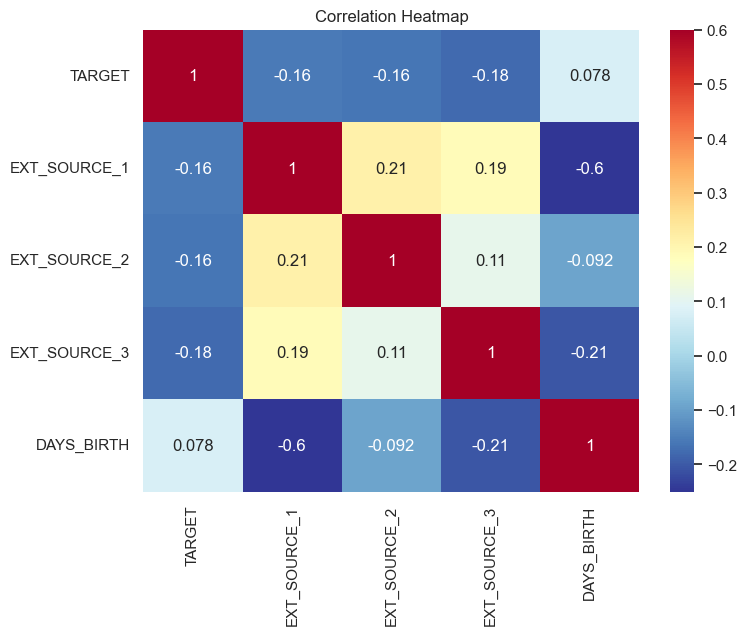

In [74]:
plt.figure(figsize = (8, 6))

# Heatmap of correlations
sns.heatmap(ext_data_corrs, cmap = plt.cm.RdYlBu_r, vmin = -0.25, annot = True, vmax = 0.6)
plt.title('Correlation Heatmap');

## entre features

In [75]:
# corrélations inter features
df.corr(numeric_only=True).abs().unstack().sort_values(ascending=False).drop_duplicates()


SK_ID_CURR                    SK_ID_CURR                  1.000000
DAYS_BIRTH                    AGE_YEARS                   1.000000
DAYS_EMPLOYED                 FLAG_EMP_PHONE              0.999755
YEARS_BUILD_MEDI              YEARS_BUILD_AVG             0.998495
OBS_60_CNT_SOCIAL_CIRCLE      OBS_30_CNT_SOCIAL_CIRCLE    0.998490
                                                            ...   
YEARS_BEGINEXPLUATATION_AVG   FLAG_DOCUMENT_4             0.000007
YEARS_BEGINEXPLUATATION_MODE  FLAG_DOCUMENT_4             0.000005
FLAG_MOBIL                    FLAG_DOCUMENT_12            0.000005
AMT_REQ_CREDIT_BUREAU_HOUR    BASEMENTAREA_MODE           0.000004
FLAG_MOBIL                    EXT_SOURCE_1                     NaN
Length: 5745, dtype: float64

## bureau.csv

#### Chargement et Statistiques

In [76]:
df_bureau = pd.read_csv(DATA_DIR / "bureau.csv")
print(df_bureau.shape)
display(df_bureau.head())
print(df_bureau.info(verbose=True))
display(df_bureau.isna().sum() / df_bureau.shape[0])

(1716428, 17)


,SK_ID_CURR,SK_ID_BUREAU,CREDIT_ACTIVE,CREDIT_CURRENCY,DAYS_CREDIT,CREDIT_DAY_OVERDUE,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,AMT_CREDIT_MAX_OVERDUE,CNT_CREDIT_PROLONG,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_LIMIT,AMT_CREDIT_SUM_OVERDUE,CREDIT_TYPE,DAYS_CREDIT_UPDATE,AMT_ANNUITY
0,215354,5714462,Closed,currency 1,-497,0,-153.0,-153.0,NaN,0,91323.0,0.0,NaN,0.0,Consumer credit,-131,NaN
1,215354,5714463,Active,currency 1,-208,0,1075.0,NaN,NaN,0,225000.0,171342.0,NaN,0.0,Credit card,-20,NaN
2,215354,5714464,Active,currency 1,-203,0,528.0,NaN,NaN,0,464323.5,NaN,NaN,0.0,Consumer credit,-16,NaN
3,215354,5714465,Active,currency 1,-203,0,NaN,NaN,NaN,0,90000.0,NaN,NaN,0.0,Credit card,-16,NaN
4,215354,5714466,Active,currency 1,-629,0,1197.0,NaN,77674.5,0,2700000.0,NaN,NaN,0.0,Consumer credit,-21,NaN


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1716428 entries, 0 to 1716427
Data columns (total 17 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   SK_ID_CURR              int64  
 1   SK_ID_BUREAU            int64  
 2   CREDIT_ACTIVE           object 
 3   CREDIT_CURRENCY         object 
 4   DAYS_CREDIT             int64  
 5   CREDIT_DAY_OVERDUE      int64  
 6   DAYS_CREDIT_ENDDATE     float64
 7   DAYS_ENDDATE_FACT       float64
 8   AMT_CREDIT_MAX_OVERDUE  float64
 9   CNT_CREDIT_PROLONG      int64  
 10  AMT_CREDIT_SUM          float64
 11  AMT_CREDIT_SUM_DEBT     float64
 12  AMT_CREDIT_SUM_LIMIT    float64
 13  AMT_CREDIT_SUM_OVERDUE  float64
 14  CREDIT_TYPE             object 
 15  DAYS_CREDIT_UPDATE      int64  
 16  AMT_ANNUITY             float64
dtypes: float64(8), int64(6), object(3)
memory usage: 222.6+ MB
None


SK_ID_CURR                0.000000
SK_ID_BUREAU              0.000000
CREDIT_ACTIVE             0.000000
CREDIT_CURRENCY           0.000000
DAYS_CREDIT               0.000000
CREDIT_DAY_OVERDUE        0.000000
DAYS_CREDIT_ENDDATE       0.061496
DAYS_ENDDATE_FACT         0.369170
AMT_CREDIT_MAX_OVERDUE    0.655133
CNT_CREDIT_PROLONG        0.000000
AMT_CREDIT_SUM            0.000008
AMT_CREDIT_SUM_DEBT       0.150119
AMT_CREDIT_SUM_LIMIT      0.344774
AMT_CREDIT_SUM_OVERDUE    0.000000
CREDIT_TYPE               0.000000
DAYS_CREDIT_UPDATE        0.000000
AMT_ANNUITY               0.714735
dtype: float64

## bureau_balance.csv

#### Chargement et Statistiques

In [77]:
df_bureau_balance = pd.read_csv(DATA_DIR / "bureau_balance.csv")
print(df_bureau_balance.shape)
display(df_bureau_balance.head())
print(df_bureau_balance.info(verbose=True))
display(df_bureau_balance.isna().sum() / df_bureau_balance.shape[0])

(27299925, 3)


,SK_ID_BUREAU,MONTHS_BALANCE,STATUS
0,5715448,0,C
1,5715448,-1,C
2,5715448,-2,C
3,5715448,-3,C
4,5715448,-4,C


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27299925 entries, 0 to 27299924
Data columns (total 3 columns):
 #   Column          Dtype 
---  ------          ----- 
 0   SK_ID_BUREAU    int64 
 1   MONTHS_BALANCE  int64 
 2   STATUS          object
dtypes: int64(2), object(1)
memory usage: 624.8+ MB
None


SK_ID_BUREAU      0.0
MONTHS_BALANCE    0.0
STATUS            0.0
dtype: float64

## credit_card_balance.csv

#### Chargement et Statistiques

In [78]:
df_credit_card_balance = pd.read_csv(DATA_DIR / "credit_card_balance.csv")
print(df_credit_card_balance.shape)
display(df_credit_card_balance.head())
print(df_credit_card_balance.info(verbose=True))
display(df_credit_card_balance.isna().sum() / df_credit_card_balance.shape[0])

(3840312, 23)


,SK_ID_PREV,SK_ID_CURR,MONTHS_BALANCE,AMT_BALANCE,AMT_CREDIT_LIMIT_ACTUAL,AMT_DRAWINGS_ATM_CURRENT,AMT_DRAWINGS_CURRENT,AMT_DRAWINGS_OTHER_CURRENT,AMT_DRAWINGS_POS_CURRENT,AMT_INST_MIN_REGULARITY,...,AMT_RECIVABLE,AMT_TOTAL_RECEIVABLE,CNT_DRAWINGS_ATM_CURRENT,CNT_DRAWINGS_CURRENT,CNT_DRAWINGS_OTHER_CURRENT,CNT_DRAWINGS_POS_CURRENT,CNT_INSTALMENT_MATURE_CUM,NAME_CONTRACT_STATUS,SK_DPD,SK_DPD_DEF
0,2562384,378907,-6,56.970,135000,0.0,877.5,0.0,877.5,1700.325,...,0.000,0.000,0.0,1,0.0,1.0,35.0,Active,0,0
1,2582071,363914,-1,63975.555,45000,2250.0,2250.0,0.0,0.0,2250.000,...,64875.555,64875.555,1.0,1,0.0,0.0,69.0,Active,0,0
2,1740877,371185,-7,31815.225,450000,0.0,0.0,0.0,0.0,2250.000,...,31460.085,31460.085,0.0,0,0.0,0.0,30.0,Active,0,0
3,1389973,337855,-4,236572.110,225000,2250.0,2250.0,0.0,0.0,11795.760,...,233048.970,233048.970,1.0,1,0.0,0.0,10.0,Active,0,0
4,1891521,126868,-1,453919.455,450000,0.0,11547.0,0.0,11547.0,22924.890,...,453919.455,453919.455,0.0,1,0.0,1.0,101.0,Active,0,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3840312 entries, 0 to 3840311
Data columns (total 23 columns):
 #   Column                      Dtype  
---  ------                      -----  
 0   SK_ID_PREV                  int64  
 1   SK_ID_CURR                  int64  
 2   MONTHS_BALANCE              int64  
 3   AMT_BALANCE                 float64
 4   AMT_CREDIT_LIMIT_ACTUAL     int64  
 5   AMT_DRAWINGS_ATM_CURRENT    float64
 6   AMT_DRAWINGS_CURRENT        float64
 7   AMT_DRAWINGS_OTHER_CURRENT  float64
 8   AMT_DRAWINGS_POS_CURRENT    float64
 9   AMT_INST_MIN_REGULARITY     float64
 10  AMT_PAYMENT_CURRENT         float64
 11  AMT_PAYMENT_TOTAL_CURRENT   float64
 12  AMT_RECEIVABLE_PRINCIPAL    float64
 13  AMT_RECIVABLE               float64
 14  AMT_TOTAL_RECEIVABLE        float64
 15  CNT_DRAWINGS_ATM_CURRENT    float64
 16  CNT_DRAWINGS_CURRENT        int64  
 17  CNT_DRAWINGS_OTHER_CURRENT  float64
 18  CNT_DRAWINGS_POS_CURRENT    float64
 19  CNT_INSTALMENT_MATURE

SK_ID_PREV                    0.000000
SK_ID_CURR                    0.000000
MONTHS_BALANCE                0.000000
AMT_BALANCE                   0.000000
AMT_CREDIT_LIMIT_ACTUAL       0.000000
AMT_DRAWINGS_ATM_CURRENT      0.195249
AMT_DRAWINGS_CURRENT          0.000000
AMT_DRAWINGS_OTHER_CURRENT    0.195249
AMT_DRAWINGS_POS_CURRENT      0.195249
AMT_INST_MIN_REGULARITY       0.079482
AMT_PAYMENT_CURRENT           0.199981
AMT_PAYMENT_TOTAL_CURRENT     0.000000
AMT_RECEIVABLE_PRINCIPAL      0.000000
AMT_RECIVABLE                 0.000000
AMT_TOTAL_RECEIVABLE          0.000000
CNT_DRAWINGS_ATM_CURRENT      0.195249
CNT_DRAWINGS_CURRENT          0.000000
CNT_DRAWINGS_OTHER_CURRENT    0.195249
CNT_DRAWINGS_POS_CURRENT      0.195249
CNT_INSTALMENT_MATURE_CUM     0.079482
NAME_CONTRACT_STATUS          0.000000
SK_DPD                        0.000000
SK_DPD_DEF                    0.000000
dtype: float64

## installments_payments.csv

#### Chargement et Statistiques

In [79]:
df_installments_payments = pd.read_csv(DATA_DIR / "installments_payments.csv")
print(df_installments_payments.shape)
display(df_installments_payments.head())
print(df_installments_payments.info(verbose=True))
display(df_installments_payments.isna().sum() / df_installments_payments.shape[0])

(13605401, 8)


,SK_ID_PREV,SK_ID_CURR,NUM_INSTALMENT_VERSION,NUM_INSTALMENT_NUMBER,DAYS_INSTALMENT,DAYS_ENTRY_PAYMENT,AMT_INSTALMENT,AMT_PAYMENT
0,1054186,161674,1.0,6,-1180.0,-1187.0,6948.360,6948.360
1,1330831,151639,0.0,34,-2156.0,-2156.0,1716.525,1716.525
2,2085231,193053,2.0,1,-63.0,-63.0,25425.000,25425.000
3,2452527,199697,1.0,3,-2418.0,-2426.0,24350.130,24350.130
4,2714724,167756,1.0,2,-1383.0,-1366.0,2165.040,2160.585


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13605401 entries, 0 to 13605400
Data columns (total 8 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   SK_ID_PREV              int64  
 1   SK_ID_CURR              int64  
 2   NUM_INSTALMENT_VERSION  float64
 3   NUM_INSTALMENT_NUMBER   int64  
 4   DAYS_INSTALMENT         float64
 5   DAYS_ENTRY_PAYMENT      float64
 6   AMT_INSTALMENT          float64
 7   AMT_PAYMENT             float64
dtypes: float64(5), int64(3)
memory usage: 830.4 MB
None


SK_ID_PREV                0.000000
SK_ID_CURR                0.000000
NUM_INSTALMENT_VERSION    0.000000
NUM_INSTALMENT_NUMBER     0.000000
DAYS_INSTALMENT           0.000000
DAYS_ENTRY_PAYMENT        0.000214
AMT_INSTALMENT            0.000000
AMT_PAYMENT               0.000214
dtype: float64

## POS_CASH_balance.csv

#### Chargement et Statistiques

In [80]:
df_POS_CASH_balance = pd.read_csv(DATA_DIR / "POS_CASH_balance.csv")
print(df_POS_CASH_balance.shape)
display(df_POS_CASH_balance.head())
print(df_POS_CASH_balance.info(verbose=True))
display(df_POS_CASH_balance.isna().sum() / df_POS_CASH_balance.shape[0])

(10001358, 8)


,SK_ID_PREV,SK_ID_CURR,MONTHS_BALANCE,CNT_INSTALMENT,CNT_INSTALMENT_FUTURE,NAME_CONTRACT_STATUS,SK_DPD,SK_DPD_DEF
0,1803195,182943,-31,48.0,45.0,Active,0,0
1,1715348,367990,-33,36.0,35.0,Active,0,0
2,1784872,397406,-32,12.0,9.0,Active,0,0
3,1903291,269225,-35,48.0,42.0,Active,0,0
4,2341044,334279,-35,36.0,35.0,Active,0,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10001358 entries, 0 to 10001357
Data columns (total 8 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   SK_ID_PREV             int64  
 1   SK_ID_CURR             int64  
 2   MONTHS_BALANCE         int64  
 3   CNT_INSTALMENT         float64
 4   CNT_INSTALMENT_FUTURE  float64
 5   NAME_CONTRACT_STATUS   object 
 6   SK_DPD                 int64  
 7   SK_DPD_DEF             int64  
dtypes: float64(2), int64(5), object(1)
memory usage: 610.4+ MB
None


SK_ID_PREV               0.000000
SK_ID_CURR               0.000000
MONTHS_BALANCE           0.000000
CNT_INSTALMENT           0.002607
CNT_INSTALMENT_FUTURE    0.002608
NAME_CONTRACT_STATUS     0.000000
SK_DPD                   0.000000
SK_DPD_DEF               0.000000
dtype: float64

## previous_application.csv

#### Chargement et Statistiques

In [81]:
df_previous_application = pd.read_csv(DATA_DIR / "previous_application.csv")
print(df_previous_application.shape)
display(df_previous_application.head())
print(df_previous_application.info(verbose=True))
display(df_previous_application.isna().sum() / df_previous_application.shape[0])

(1670214, 37)


,SK_ID_PREV,SK_ID_CURR,NAME_CONTRACT_TYPE,AMT_ANNUITY,AMT_APPLICATION,AMT_CREDIT,AMT_DOWN_PAYMENT,AMT_GOODS_PRICE,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,...,NAME_SELLER_INDUSTRY,CNT_PAYMENT,NAME_YIELD_GROUP,PRODUCT_COMBINATION,DAYS_FIRST_DRAWING,DAYS_FIRST_DUE,DAYS_LAST_DUE_1ST_VERSION,DAYS_LAST_DUE,DAYS_TERMINATION,NFLAG_INSURED_ON_APPROVAL
0,2030495,271877,Consumer loans,1730.430,17145.0,17145.0,0.0,17145.0,SATURDAY,15,...,Connectivity,12.0,middle,POS mobile with interest,365243.0,-42.0,300.0,-42.0,-37.0,0.0
1,2802425,108129,Cash loans,25188.615,607500.0,679671.0,NaN,607500.0,THURSDAY,11,...,XNA,36.0,low_action,Cash X-Sell: low,365243.0,-134.0,916.0,365243.0,365243.0,1.0
2,2523466,122040,Cash loans,15060.735,112500.0,136444.5,NaN,112500.0,TUESDAY,11,...,XNA,12.0,high,Cash X-Sell: high,365243.0,-271.0,59.0,365243.0,365243.0,1.0
3,2819243,176158,Cash loans,47041.335,450000.0,470790.0,NaN,450000.0,MONDAY,7,...,XNA,12.0,middle,Cash X-Sell: middle,365243.0,-482.0,-152.0,-182.0,-177.0,1.0
4,1784265,202054,Cash loans,31924.395,337500.0,404055.0,NaN,337500.0,THURSDAY,9,...,XNA,24.0,high,Cash Street: high,NaN,NaN,NaN,NaN,NaN,NaN


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1670214 entries, 0 to 1670213
Data columns (total 37 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   SK_ID_PREV                   1670214 non-null  int64  
 1   SK_ID_CURR                   1670214 non-null  int64  
 2   NAME_CONTRACT_TYPE           1670214 non-null  object 
 3   AMT_ANNUITY                  1297979 non-null  float64
 4   AMT_APPLICATION              1670214 non-null  float64
 5   AMT_CREDIT                   1670213 non-null  float64
 6   AMT_DOWN_PAYMENT             774370 non-null   float64
 7   AMT_GOODS_PRICE              1284699 non-null  float64
 8   WEEKDAY_APPR_PROCESS_START   1670214 non-null  object 
 9   HOUR_APPR_PROCESS_START      1670214 non-null  int64  
 10  FLAG_LAST_APPL_PER_CONTRACT  1670214 non-null  object 
 11  NFLAG_LAST_APPL_IN_DAY       1670214 non-null  int64  
 12  RATE_DOWN_PAYMENT            774370 non-nu

SK_ID_PREV                     0.000000e+00
SK_ID_CURR                     0.000000e+00
NAME_CONTRACT_TYPE             0.000000e+00
AMT_ANNUITY                    2.228667e-01
AMT_APPLICATION                0.000000e+00
AMT_CREDIT                     5.987257e-07
AMT_DOWN_PAYMENT               5.363648e-01
AMT_GOODS_PRICE                2.308177e-01
WEEKDAY_APPR_PROCESS_START     0.000000e+00
HOUR_APPR_PROCESS_START        0.000000e+00
FLAG_LAST_APPL_PER_CONTRACT    0.000000e+00
NFLAG_LAST_APPL_IN_DAY         0.000000e+00
RATE_DOWN_PAYMENT              5.363648e-01
RATE_INTEREST_PRIMARY          9.964370e-01
RATE_INTEREST_PRIVILEGED       9.964370e-01
NAME_CASH_LOAN_PURPOSE         0.000000e+00
NAME_CONTRACT_STATUS           0.000000e+00
DAYS_DECISION                  0.000000e+00
NAME_PAYMENT_TYPE              0.000000e+00
CODE_REJECT_REASON             0.000000e+00
NAME_TYPE_SUITE                4.911975e-01
NAME_CLIENT_TYPE               0.000000e+00
NAME_GOODS_CATEGORY            0

## Application_test.csv

In [82]:
df_test = pd.read_csv(DATA_DIR / "application_test.csv")
print(df_test.shape)
df_test.head()

(48744, 121)


,SK_ID_CURR,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100001,Cash loans,F,N,Y,0,135000.0,568800.0,20560.5,450000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
1,100005,Cash loans,M,N,Y,0,99000.0,222768.0,17370.0,180000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,3.0
2,100013,Cash loans,M,Y,Y,0,202500.0,663264.0,69777.0,630000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,1.0,4.0
3,100028,Cash loans,F,N,Y,2,315000.0,1575000.0,49018.5,1575000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,3.0
4,100038,Cash loans,M,Y,N,1,180000.0,625500.0,32067.0,625500.0,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN


## Synthèse EDA

Cette analyse exploratoire ciblée met en évidence plusieurs signaux cohérents
avec les enjeux du scoring crédit :
- l’âge,
- le niveau de revenu,
- la charge de remboursement.

Ces variables constituent des candidates naturelles pour la phase
de préparation des données et de feature engineering.

Corrélations :
Les features sont en général peu corrélées avec la cible.
Le features engineering permettra d'améliorer les performances.

# Feature engineering

## bureau / bureau_balance

### Fonction bureau_and_balance

In [83]:
def one_hot_encoder_return_newcols(df, nan_as_category=True):
    original_cols = df.columns.tolist()
    cat_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()
    df = pd.get_dummies(df, columns=cat_cols, dummy_na=nan_as_category)
    new_cols = [c for c in df.columns if c not in original_cols]
    return df, new_cols

def bureau_and_balance_reduced(data_dir=DATA_DIR, num_rows=None, nan_as_category=True):
    """
    Version réduite, orientée compréhension.
    Sortie : 1 ligne par SK_ID_CURR, features numériques uniquement.
    """

    # -------------------------
    # 1) Load
    # -------------------------
    bureau = pd.read_csv(f"{data_dir}/bureau.csv", nrows=num_rows)
    bb = pd.read_csv(f"{data_dir}/bureau_balance.csv", nrows=num_rows)

    # -------------------------
    # 2) bureau_balance -> SK_ID_BUREAU
    # -------------------------
    bb, bb_cat = one_hot_encoder_return_newcols(bb, nan_as_category=nan_as_category)

    # On garde seulement quelques statuts "clés" si présents
    keep_status = [
        "STATUS_0", "STATUS_1", "STATUS_2", "STATUS_3", "STATUS_4", "STATUS_5", "STATUS_C", "STATUS_X"
    ]
    keep_bb_cols = [c for c in bb_cat if any(c.endswith(s) or c == s for s in keep_status)]
    # Remarque: selon Kaggle, les colonnes peuvent s'appeler STATUS_0 ou STATUS_0. Ici on couvre large.
    # Si ta one-hot produit exactement STATUS_0, STATUS_1... alors keep_bb_cols marche.

    bb_aggs = {
        "MONTHS_BALANCE": ["min", "count"],  # ancienneté + longueur d'historique
    }
    for c in keep_bb_cols:
        bb_aggs[c] = ["mean"]  # fréquence du statut sur l'historique

    bb_agg = bb.groupby("SK_ID_BUREAU").agg(bb_aggs)
    bb_agg.columns = [f"BB_{col}_{stat.upper()}" for col, stat in bb_agg.columns]

    del bb
    gc.collect()

    # -------------------------
    # 3) Merge into bureau (crédit enrichi avec historique résumé)
    # -------------------------
    bureau = bureau.merge(bb_agg, how="left", on="SK_ID_BUREAU")

    # -------------------------
    # 4) bureau -> SK_ID_CURR (features réduites)
    # -------------------------
    # OHE seulement pour avoir CREDIT_ACTIVE_Active en proportion
    bureau_ohe, bureau_cat = one_hot_encoder_return_newcols(bureau, nan_as_category=nan_as_category)

    # Quelques colonnes numériques clés (si présentes)
    key_num_cols = [
        "DAYS_CREDIT",
        "CREDIT_DAY_OVERDUE",
        "AMT_CREDIT_SUM",
        "AMT_CREDIT_SUM_DEBT",
        "CNT_CREDIT_PROLONG",
    ]
    # On ajoute les colonnes BB_* créées
    bb_num_cols = [c for c in bureau_ohe.columns if c.startswith("BB_")]

    # On garde uniquement celles qui existent
    key_num_cols = [c for c in key_num_cols if c in bureau_ohe.columns]

    # Features globales au niveau client
    aggs = {}

    # nombre de crédits bureau
    aggs["DAYS_CREDIT"] = ["count", "min", "max"] if "DAYS_CREDIT" in bureau_ohe.columns else ["count"]

    # Endettement / exposition
    if "AMT_CREDIT_SUM" in bureau_ohe.columns:
        aggs["AMT_CREDIT_SUM"] = ["sum", "max"]
    if "AMT_CREDIT_SUM_DEBT" in bureau_ohe.columns:
        aggs["AMT_CREDIT_SUM_DEBT"] = ["sum"]

    # Retards / prolongations
    if "CREDIT_DAY_OVERDUE" in bureau_ohe.columns:
        aggs["CREDIT_DAY_OVERDUE"] = ["max"]
    if "CNT_CREDIT_PROLONG" in bureau_ohe.columns:
        aggs["CNT_CREDIT_PROLONG"] = ["sum"]

    # Infos d'historique bureau_balance résumées (au niveau crédit)
    # au niveau client, on prend:
    # - MIN de BB_MONTHS_BALANCE_MIN : crédit le plus ancien
    # - MEAN de BB_MONTHS_BALANCE_COUNT : longueur moyenne d'historique
    # - MEAN des fréquences de statuts (moyenne des fréquences par crédit)
    bb_cols_min = [c for c in bb_num_cols if c.endswith("_MIN")]
    bb_cols_count = [c for c in bb_num_cols if c.endswith("_COUNT")]
    bb_cols_mean = [c for c in bb_num_cols if c.endswith("_MEAN")]

    for c in bb_cols_min:
        aggs[c] = ["min"]
    for c in bb_cols_count:
        aggs[c] = ["mean"]
    for c in bb_cols_mean:
        aggs[c] = ["mean"]

    # Proportion de crédits actifs (si existe)
    if "CREDIT_ACTIVE_Active" in bureau_ohe.columns:
        aggs["CREDIT_ACTIVE_Active"] = ["mean"]

    buro_agg = bureau_ohe.groupby("SK_ID_CURR").agg(aggs)
    buro_agg.columns = [f"BURO_{col}_{stat.upper()}" for col, stat in buro_agg.columns]

    # -------------------------
    # 5) Active / Closed (réduit)
    # -------------------------
    def agg_subset(df, prefix):
        sub_aggs = {}
        if "AMT_CREDIT_SUM" in df.columns:
            sub_aggs["AMT_CREDIT_SUM"] = ["sum"]
        if "AMT_CREDIT_SUM_DEBT" in df.columns:
            sub_aggs["AMT_CREDIT_SUM_DEBT"] = ["sum"]
        if "CREDIT_DAY_OVERDUE" in df.columns:
            sub_aggs["CREDIT_DAY_OVERDUE"] = ["max"]
        if not sub_aggs:
            return None
        out = df.groupby("SK_ID_CURR").agg(sub_aggs)
        out.columns = [f"{prefix}_{col}_{stat.upper()}" for col, stat in out.columns]
        return out

    if "CREDIT_ACTIVE_Active" in bureau_ohe.columns:
        active_df = bureau_ohe[bureau_ohe["CREDIT_ACTIVE_Active"] == 1]
        active_agg = agg_subset(active_df, "BURO_ACTIVE")
        if active_agg is not None:
            buro_agg = buro_agg.join(active_agg, how="left")

    if "CREDIT_ACTIVE_Closed" in bureau_ohe.columns:
        closed_df = bureau_ohe[bureau_ohe["CREDIT_ACTIVE_Closed"] == 1]
        closed_agg = agg_subset(closed_df, "BURO_CLOSED")
        if closed_agg is not None:
            buro_agg = buro_agg.join(closed_agg, how="left")

    # Nettoyage
    del bureau, bureau_ohe
    gc.collect()

    # sécurité : uniquement numérique
    non_num = buro_agg.select_dtypes(exclude=[np.number]).columns.tolist()
    if non_num:
        raise ValueError(f"Non-numeric columns in output: {non_num[:10]}")

    return buro_agg


### Test fonction

In [84]:
buro = bureau_and_balance_reduced(data_dir=DATA_DIR, num_rows=50000)
print(buro.shape)
print(buro.isna().mean().sort_values(ascending=False).head(10))


(10171, 25)
BURO_BB_STATUS_2_MEAN_MEAN           0.988202
BURO_BB_STATUS_5_MEAN_MEAN           0.988202
BURO_BB_STATUS_X_MEAN_MEAN           0.988202
BURO_BB_MONTHS_BALANCE_MIN_MIN       0.988202
BURO_BB_MONTHS_BALANCE_COUNT_MEAN    0.988202
BURO_BB_STATUS_0_MEAN_MEAN           0.988202
BURO_BB_STATUS_1_MEAN_MEAN           0.988202
BURO_BB_STATUS_C_MEAN_MEAN           0.988202
BURO_BB_STATUS_3_MEAN_MEAN           0.988202
BURO_BB_STATUS_4_MEAN_MEAN           0.988202
dtype: float64


In [85]:
# seuil clair et justifiable
na_threshold = 0.95

cols_to_drop = buro.columns[buro.isna().mean() > na_threshold]
print(f"Colonnes supprimées (> {na_threshold*100:.0f}% NaN):", cols_to_drop.tolist())

buro_clean = buro.drop(columns=cols_to_drop)
print("Nouvelle shape:", buro_clean.shape)
buro_clean.head()

Colonnes supprimées (> 95% NaN): ['BURO_BB_MONTHS_BALANCE_MIN_MIN', 'BURO_BB_MONTHS_BALANCE_COUNT_MEAN', 'BURO_BB_STATUS_0_MEAN_MEAN', 'BURO_BB_STATUS_1_MEAN_MEAN', 'BURO_BB_STATUS_2_MEAN_MEAN', 'BURO_BB_STATUS_3_MEAN_MEAN', 'BURO_BB_STATUS_4_MEAN_MEAN', 'BURO_BB_STATUS_5_MEAN_MEAN', 'BURO_BB_STATUS_C_MEAN_MEAN', 'BURO_BB_STATUS_X_MEAN_MEAN']
Nouvelle shape: (10171, 15)


,BURO_DAYS_CREDIT_COUNT,BURO_DAYS_CREDIT_MIN,BURO_DAYS_CREDIT_MAX,BURO_AMT_CREDIT_SUM_SUM,BURO_AMT_CREDIT_SUM_MAX,BURO_AMT_CREDIT_SUM_DEBT_SUM,BURO_CREDIT_DAY_OVERDUE_MAX,BURO_CNT_CREDIT_PROLONG_SUM,BURO_CREDIT_ACTIVE_Active_MEAN,BURO_ACTIVE_AMT_CREDIT_SUM_SUM,BURO_ACTIVE_AMT_CREDIT_SUM_DEBT_SUM,BURO_ACTIVE_CREDIT_DAY_OVERDUE_MAX,BURO_CLOSED_AMT_CREDIT_SUM_SUM,BURO_CLOSED_AMT_CREDIT_SUM_DEBT_SUM,BURO_CLOSED_CREDIT_DAY_OVERDUE_MAX
SK_ID_CURR,,,,,,,,,,,,,,,
100016,6,-1634,-128,407484.000,91264.500,63724.500,0,0,0.500000,269257.5,63724.500,0.0,138226.500,0.0,0.0
100053,7,-2893,-1764,648589.500,225000.000,0.000,0,0,0.142857,48820.5,0.000,0.0,599769.000,0.0,0.0
100165,2,-2325,-1225,118068.480,64104.480,0.000,0,0,0.000000,NaN,NaN,NaN,118068.480,0.0,0.0
100166,13,-2058,-106,582614.595,126121.095,106414.425,0,0,0.153846,172539.0,106414.425,0.0,410075.595,0.0,0.0
100294,5,-1137,-217,900955.170,360000.000,90522.180,0,0,0.200000,112500.0,90522.180,0.0,788455.170,0.0,0.0


### Valeurs manquantes

In [86]:
na_rate = buro.isna().mean().sort_values(ascending=False)

print("\nTop 20 colonnes les plus manquantes (taux NaN):")
print(na_rate.head(20))

print("\nRésumé NaN (%):")
print(na_rate.describe(percentiles=[.5, .75, .9, .95, .99]))



Top 20 colonnes les plus manquantes (taux NaN):
BURO_BB_STATUS_2_MEAN_MEAN             0.988202
BURO_BB_STATUS_5_MEAN_MEAN             0.988202
BURO_BB_STATUS_X_MEAN_MEAN             0.988202
BURO_BB_MONTHS_BALANCE_MIN_MIN         0.988202
BURO_BB_MONTHS_BALANCE_COUNT_MEAN      0.988202
BURO_BB_STATUS_0_MEAN_MEAN             0.988202
BURO_BB_STATUS_1_MEAN_MEAN             0.988202
BURO_BB_STATUS_C_MEAN_MEAN             0.988202
BURO_BB_STATUS_3_MEAN_MEAN             0.988202
BURO_BB_STATUS_4_MEAN_MEAN             0.988202
BURO_ACTIVE_CREDIT_DAY_OVERDUE_MAX     0.189067
BURO_ACTIVE_AMT_CREDIT_SUM_DEBT_SUM    0.189067
BURO_ACTIVE_AMT_CREDIT_SUM_SUM         0.189067
BURO_CLOSED_AMT_CREDIT_SUM_DEBT_SUM    0.135778
BURO_CLOSED_AMT_CREDIT_SUM_SUM         0.135778
BURO_CLOSED_CREDIT_DAY_OVERDUE_MAX     0.135778
BURO_DAYS_CREDIT_MIN                   0.000000
BURO_CNT_CREDIT_PROLONG_SUM            0.000000
BURO_CREDIT_ACTIVE_Active_MEAN         0.000000
BURO_CREDIT_DAY_OVERDUE_MAX            

## previous_application

### Fonction previous_application

In [87]:
def one_hot_encoder_return_newcols(df, nan_as_category=True):
    original_cols = df.columns.tolist()
    cat_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()
    df = pd.get_dummies(df, columns=cat_cols, dummy_na=nan_as_category)
    new_cols = [c for c in df.columns if c not in original_cols]
    return df, new_cols


def previous_application_reduced(data_dir=DATA_DIR, num_rows=None, nan_as_category=True):
    """
    Version réduite et explicable de previous_application.
    Sortie : 1 ligne par SK_ID_CURR, features numériques uniquement.
    """

    prev = pd.read_csv(f"{data_dir}/previous_application.csv", nrows=num_rows)

    # Nettoyage simple des sentinelles connues
    day_cols = [
        "DAYS_FIRST_DRAWING",
        "DAYS_FIRST_DUE",
        "DAYS_LAST_DUE_1ST_VERSION",
        "DAYS_LAST_DUE",
        "DAYS_TERMINATION",
    ]
    for c in day_cols:
        if c in prev.columns:
            prev[c] = prev[c].replace(365243, np.nan)

    # Feature clé : cohérence demande / offre
    prev["APP_CREDIT_PERC"] = np.where(prev["AMT_CREDIT"] != 0, prev["AMT_APPLICATION"] / prev["AMT_CREDIT"], np.nan)

    # OHE uniquement pour le statut de la demande
    prev_ohe, prev_cat = one_hot_encoder_return_newcols(prev, nan_as_category=nan_as_category)

    # Colonnes clés numériques
    key_num_cols = [
        "AMT_APPLICATION",
        "AMT_CREDIT",
        "AMT_ANNUITY",
        "APP_CREDIT_PERC",
        "DAYS_DECISION",
    ]
    key_num_cols = [c for c in key_num_cols if c in prev_ohe.columns]

    aggs = {}

    # Volume et récence
    aggs["DAYS_DECISION"] = ["count", "min", "mean"]

    # Montants
    if "AMT_APPLICATION" in prev_ohe.columns:
        aggs["AMT_APPLICATION"] = ["mean", "max"]
    if "AMT_CREDIT" in prev_ohe.columns:
        aggs["AMT_CREDIT"] = ["mean", "max"]
    if "AMT_ANNUITY" in prev_ohe.columns:
        aggs["AMT_ANNUITY"] = ["mean"]

    # Cohérence demande / offre
    if "APP_CREDIT_PERC" in prev_ohe.columns:
        aggs["APP_CREDIT_PERC"] = ["mean"]

    # Proportions Approved / Refused (si présentes)
    for col in ["NAME_CONTRACT_STATUS_Approved", "NAME_CONTRACT_STATUS_Refused"]:
        if col in prev_ohe.columns:
            aggs[col] = ["mean"]

    prev_agg = prev_ohe.groupby("SK_ID_CURR").agg(aggs)
    prev_agg.columns = [f"PREV_{col}_{stat.upper()}" for col, stat in prev_agg.columns]

    del prev, prev_ohe
    gc.collect()

    # Sécurité : uniquement numérique
    non_num = prev_agg.select_dtypes(exclude=[np.number]).columns.tolist()
    if non_num:
        raise ValueError(f"Non-numeric columns in output: {non_num[:10]}")

    return prev_agg


In [88]:
prev = previous_application_reduced(data_dir=DATA_DIR, num_rows=50000)

print(prev.shape)
print(prev.isna().mean().sort_values(ascending=False).head(10))
print(prev.columns.tolist())


(44471, 11)
PREV_AMT_ANNUITY_MEAN                      0.181422
PREV_APP_CREDIT_PERC_MEAN                  0.159655
PREV_DAYS_DECISION_COUNT                   0.000000
PREV_DAYS_DECISION_MIN                     0.000000
PREV_DAYS_DECISION_MEAN                    0.000000
PREV_AMT_APPLICATION_MEAN                  0.000000
PREV_AMT_APPLICATION_MAX                   0.000000
PREV_AMT_CREDIT_MEAN                       0.000000
PREV_AMT_CREDIT_MAX                        0.000000
PREV_NAME_CONTRACT_STATUS_Approved_MEAN    0.000000
dtype: float64
['PREV_DAYS_DECISION_COUNT', 'PREV_DAYS_DECISION_MIN', 'PREV_DAYS_DECISION_MEAN', 'PREV_AMT_APPLICATION_MEAN', 'PREV_AMT_APPLICATION_MAX', 'PREV_AMT_CREDIT_MEAN', 'PREV_AMT_CREDIT_MAX', 'PREV_AMT_ANNUITY_MEAN', 'PREV_APP_CREDIT_PERC_MEAN', 'PREV_NAME_CONTRACT_STATUS_Approved_MEAN', 'PREV_NAME_CONTRACT_STATUS_Refused_MEAN']


## installments_payments

### Fonction installments_payments

In [89]:
def installments_payments_reduced(DATA_DIR, num_rows=None):
    """
    Version réduite et explicable de installments_payments.
    Sortie : 1 ligne par SK_ID_CURR, features numériques uniquement.
    """

    ins = pd.read_csv(f"{DATA_DIR}/installments_payments.csv", nrows=num_rows)

    # -------------------------
    # 1) Features élémentaires (ligne par échéance)
    # -------------------------
    # proportion payée
    ins["PAYMENT_PERC"] = np.where(ins["AMT_INSTALMENT"] != 0, ins["AMT_PAYMENT"] / ins["AMT_INSTALMENT"], np.nan)

    # différence paiement / dû
    ins["PAYMENT_DIFF"] = np.where(ins["AMT_INSTALMENT"] != 0, ins["AMT_INSTALMENT"] - ins["AMT_PAYMENT"], np.nan)

    # jours de retard (DPD) / d'avance (DBD)
    ins["DPD"] = np.where(ins["DAYS_ENTRY_PAYMENT"] > ins["DAYS_INSTALMENT"], ins["DAYS_ENTRY_PAYMENT"] - ins["DAYS_INSTALMENT"], 0)
    ins["DBD"] = np.where(ins["DAYS_ENTRY_PAYMENT"] < ins["DAYS_INSTALMENT"], ins["DAYS_INSTALMENT"] - ins["DAYS_ENTRY_PAYMENT"], 0)

    # -------------------------
    # 2) Agrégation au niveau client
    # -------------------------
    aggs = {
        "DPD": ["max", "mean"],
        "DBD": ["mean"],
        "PAYMENT_PERC": ["mean"],
        "PAYMENT_DIFF": ["sum"],
        "AMT_PAYMENT": ["sum"],
        "AMT_INSTALMENT": ["sum"],
    }

    ins_agg = ins.groupby("SK_ID_CURR").agg(aggs)
    ins_agg.columns = [f"INSTAL_{col}_{stat.upper()}" for col, stat in ins_agg.columns]

    # nombre total d'échéances
    ins_agg["INSTAL_COUNT"] = ins.groupby("SK_ID_CURR").size()

    del ins
    gc.collect()

    # sécurité : uniquement numérique
    non_num = ins_agg.select_dtypes(exclude=[np.number]).columns.tolist()
    if non_num:
        raise ValueError(f"Non-numeric columns in output: {non_num[:10]}")

    return ins_agg


### Test

In [90]:
inst = installments_payments_reduced(DATA_DIR, num_rows=50000)

print(inst.shape)
print(inst.isna().mean().sort_values(ascending=False).head(10))
print(inst.columns.tolist())


(32256, 8)
INSTAL_PAYMENT_PERC_MEAN     0.000031
INSTAL_DPD_MAX               0.000000
INSTAL_DPD_MEAN              0.000000
INSTAL_DBD_MEAN              0.000000
INSTAL_PAYMENT_DIFF_SUM      0.000000
INSTAL_AMT_PAYMENT_SUM       0.000000
INSTAL_AMT_INSTALMENT_SUM    0.000000
INSTAL_COUNT                 0.000000
dtype: float64
['INSTAL_DPD_MAX', 'INSTAL_DPD_MEAN', 'INSTAL_DBD_MEAN', 'INSTAL_PAYMENT_PERC_MEAN', 'INSTAL_PAYMENT_DIFF_SUM', 'INSTAL_AMT_PAYMENT_SUM', 'INSTAL_AMT_INSTALMENT_SUM', 'INSTAL_COUNT']


## POS_CASH

### Fonction pos_cash

In [91]:
def pos_cash_balance_reduced(DATA_DIR, num_rows=None):
    """
    Version réduite et explicable de POS_CASH_balance.
    Sortie : 1 ligne par SK_ID_CURR, features numériques uniquement.
    """

    pos = pd.read_csv(f"{DATA_DIR}/POS_CASH_balance.csv", nrows=num_rows)

    # -------------------------
    # Agrégation au niveau client
    # -------------------------
    aggs = {
        "MONTHS_BALANCE": ["min", "mean"],
        "SK_DPD": ["max", "mean"],
        "SK_DPD_DEF": ["max", "mean"],
    }

    pos_agg = pos.groupby("SK_ID_CURR").agg(aggs)
    pos_agg.columns = [f"POS_{col}_{stat.upper()}" for col, stat in pos_agg.columns]

    # nombre de lignes POS (taille de l'historique)
    pos_agg["POS_COUNT"] = pos.groupby("SK_ID_CURR").size()

    del pos
    gc.collect()

    # sécurité : uniquement numérique
    non_num = pos_agg.select_dtypes(exclude=[np.number]).columns.tolist()
    if non_num:
        raise ValueError(f"Non-numeric columns in output: {non_num[:10]}")

    return pos_agg


In [92]:
pos_feat = pos_cash_balance_reduced(DATA_DIR, num_rows=50000)

print(pos_feat.shape)
print(pos_feat.isna().mean().sort_values(ascending=False).head(10))
print(pos_feat.columns.tolist())

(42556, 7)
POS_MONTHS_BALANCE_MIN     0.0
POS_MONTHS_BALANCE_MEAN    0.0
POS_SK_DPD_MAX             0.0
POS_SK_DPD_MEAN            0.0
POS_SK_DPD_DEF_MAX         0.0
POS_SK_DPD_DEF_MEAN        0.0
POS_COUNT                  0.0
dtype: float64
['POS_MONTHS_BALANCE_MIN', 'POS_MONTHS_BALANCE_MEAN', 'POS_SK_DPD_MAX', 'POS_SK_DPD_MEAN', 'POS_SK_DPD_DEF_MAX', 'POS_SK_DPD_DEF_MEAN', 'POS_COUNT']


## credit_card_balance

### Fonction credit_card_balance

In [93]:
def credit_card_balance_reduced(DATA_DIR, num_rows=None):
    """
    Version réduite et explicable de credit_card_balance.
    Sortie : 1 ligne par SK_ID_CURR, features numériques uniquement.
    """

    cc = pd.read_csv(f"{DATA_DIR}/credit_card_balance.csv", nrows=num_rows)

    # -------------------------
    # 1) Features élémentaires (ligne par mois)
    # -------------------------
    # taux d'utilisation du crédit
    cc["CREDIT_UTIL"] = np.where(cc["AMT_CREDIT_LIMIT_ACTUAL"] != 0, cc["AMT_BALANCE"] / cc["AMT_CREDIT_LIMIT_ACTUAL"], np.nan)

    # ratio paiement / minimum requis
    cc["PAYMENT_MIN_RATIO"] = np.where(cc["AMT_INST_MIN_REGULARITY"] != 0, cc["AMT_PAYMENT_CURRENT"] / cc["AMT_INST_MIN_REGULARITY"], np.nan)

    # remplace inf / -inf par NaN (division par zéro)
    cc.replace([np.inf, -np.inf], np.nan, inplace=True)

    # -------------------------
    # 2) Agrégation au niveau client
    # -------------------------
    aggs = {
        "MONTHS_BALANCE": ["min"],
        "AMT_BALANCE": ["mean"],
        "CREDIT_UTIL": ["mean", "max"],
        "AMT_PAYMENT_CURRENT": ["mean"],
        "PAYMENT_MIN_RATIO": ["mean"],
        "SK_DPD": ["max"],
        "SK_DPD_DEF": ["max"],
    }

    cc_agg = cc.groupby("SK_ID_CURR").agg(aggs)
    cc_agg.columns = [f"CC_{col}_{stat.upper()}" for col, stat in cc_agg.columns]

    # nombre de mois observés (profondeur historique)
    cc_agg["CC_COUNT"] = cc.groupby("SK_ID_CURR").size()

    del cc
    gc.collect()

    # sécurité : uniquement numérique
    non_num = cc_agg.select_dtypes(exclude=[np.number]).columns.tolist()
    if non_num:
        raise ValueError(f"Non-numeric columns in output: {non_num[:10]}")

    return cc_agg


### Test

In [94]:
cc_feat = credit_card_balance_reduced(DATA_DIR, num_rows=50000)

print(cc_feat.shape)
print(cc_feat.isna().mean().sort_values(ascending=False).head(10))
print(cc_feat.columns.tolist())

(34417, 9)
CC_PAYMENT_MIN_RATIO_MEAN      0.531598
CC_AMT_PAYMENT_CURRENT_MEAN    0.244443
CC_CREDIT_UTIL_MEAN            0.151146
CC_CREDIT_UTIL_MAX             0.151146
CC_MONTHS_BALANCE_MIN          0.000000
CC_AMT_BALANCE_MEAN            0.000000
CC_SK_DPD_MAX                  0.000000
CC_SK_DPD_DEF_MAX              0.000000
CC_COUNT                       0.000000
dtype: float64
['CC_MONTHS_BALANCE_MIN', 'CC_AMT_BALANCE_MEAN', 'CC_CREDIT_UTIL_MEAN', 'CC_CREDIT_UTIL_MAX', 'CC_AMT_PAYMENT_CURRENT_MEAN', 'CC_PAYMENT_MIN_RATIO_MEAN', 'CC_SK_DPD_MAX', 'CC_SK_DPD_DEF_MAX', 'CC_COUNT']


## application_train / test

### chargement + création features

In [95]:
def load_application_train(DATA_DIR):
    app = pd.read_csv(f"{DATA_DIR}/application_train.csv")

    # nettoyage minimal et justifié
    app = app[app["CODE_GENDER"] != "XNA"].copy()
    app["DAYS_EMPLOYED"] = app["DAYS_EMPLOYED"].replace(365243, np.nan)

    # quelques ratios simples (optionnels mais utiles)
    app["PAYMENT_RATE"] = np.where(app["AMT_CREDIT"] != 0, app["AMT_ANNUITY"] / app["AMT_CREDIT"], np.nan)
    app["INCOME_CREDIT_PERC"] = np.where(app["AMT_CREDIT"] != 0, app["AMT_INCOME_TOTAL"] / app["AMT_CREDIT"], np.nan)
    app["ANNUITY_INCOME_PERC"] = np.where(app["AMT_INCOME_TOTAL"] != 0, app["AMT_ANNUITY"] / app["AMT_INCOME_TOTAL"], np.nan)

    return app


def load_application_test(DATA_DIR):
    app = pd.read_csv(f"{DATA_DIR}/application_test.csv")

    app = app[app["CODE_GENDER"] != "XNA"].copy()
    app["DAYS_EMPLOYED"] = app["DAYS_EMPLOYED"].replace(365243, np.nan)

    app["PAYMENT_RATE"] = np.where(app["AMT_CREDIT"] != 0, app["AMT_ANNUITY"] / app["AMT_CREDIT"], np.nan)
    app["INCOME_CREDIT_PERC"] = np.where(app["AMT_CREDIT"] != 0, app["AMT_INCOME_TOTAL"] / app["AMT_CREDIT"], np.nan)
    app["ANNUITY_INCOME_PERC"] = np.where(app["AMT_INCOME_TOTAL"] != 0, app["AMT_ANNUITY"] / app["AMT_INCOME_TOTAL"], np.nan)

    return app

### application_test

In [96]:
# bureau
buro = bureau_and_balance_reduced(DATA_DIR)

# previous applications
prev = previous_application_reduced(DATA_DIR)

# installments
inst = installments_payments_reduced(DATA_DIR)

# POS cash
pos = pos_cash_balance_reduced(DATA_DIR)

# credit card
cc = credit_card_balance_reduced(DATA_DIR)


### assemblage train

In [97]:
app_labeled = load_application_train(DATA_DIR)

y = app_labeled["TARGET"]
X = app_labeled.drop(columns=["TARGET"])

X = (
    X
    .join(buro, on="SK_ID_CURR")
    .join(prev, on="SK_ID_CURR")
    .join(inst, on="SK_ID_CURR")
    .join(pos, on="SK_ID_CURR")
    .join(cc, on="SK_ID_CURR")
)

print("X_labeled shape:", X.shape)


X_labeled shape: (307507, 184)


### assemblage_test

In [98]:
app_scoring = load_application_test(DATA_DIR)

X_scoring = (
    app_scoring
    .join(buro, on="SK_ID_CURR")
    .join(prev, on="SK_ID_CURR")
    .join(inst, on="SK_ID_CURR")
    .join(pos, on="SK_ID_CURR")
    .join(cc, on="SK_ID_CURR")
)

print("X_scoring shape:", X_scoring.shape)


X_scoring shape: (48744, 184)


### Sauvegarde de X_scoring pour les tests

In [99]:
# Sauvegarde du features store pour l'API
X_scoring.to_parquet("api/models/features_store.parquet", index=False)
print("features_store.parquet sauvegardé :", X_scoring.shape)

features_store.parquet sauvegardé : (48744, 184)


In [100]:
assert set(X.columns) == set(X_scoring.columns)

In [101]:
print("Catégorielles :", X.select_dtypes(include=["object", "category"]).shape[1])
print("Numériques   :", X.select_dtypes(include=[np.number]).shape[1])

Catégorielles : 16
Numériques   : 168


# Preprocessing

## Nettoyage

### Valeurs manquantes

In [102]:
threshold = 0.9
cols_to_drop = missing_rate[missing_rate > threshold].index

len(cols_to_drop)

0

In [103]:
X = X.drop(columns=cols_to_drop)
X.shape

(307507, 184)

In [104]:
def make_preprocessor(X: pd.DataFrame) -> ColumnTransformer:
    X_ = X.drop(columns=["SK_ID_CURR"])

    num_cols = X_.select_dtypes(include=[np.number]).columns.tolist()
    cat_cols = X_.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

    numeric_pipe = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler(with_mean=False)),
    ])

    categorical_pipe = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=True)),
    ])

    return ColumnTransformer(
        transformers=[
            ("num", numeric_pipe, num_cols),
            ("cat", categorical_pipe, cat_cols),
        ],
        remainder="drop"
    )

# MODELISATION

## Fractionnement des données

In [105]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((246005, 184), (61502, 184), (246005,), (61502,))

## Initialisation
> Configuration commune à tous les runs (modèles)

### Initialisation mlflow

In [162]:
# initialisation mlflow
mlflow.set_tracking_uri("sqlite:///mlflow.db")
# mlflow.set_tracking_uri("http://127.0.0.1:5000")
EXPERIMENT_NAME = "OC - Projet 7 - Scoring Model - 9.0"
mlflow.set_experiment(EXPERIMENT_NAME)
# logger de mlflow
# mlflow.sklearn.autolog() # => on préférera logger manuellement pour plus de contrôle et de clarté dans les métriques et paramètres enregistrés.


2026/02/22 17:21:37 INFO mlflow.tracking.fluent: Experiment with name 'OC - Projet 7 - Scoring Model - 9.0' does not exist. Creating a new experiment.


<Experiment: artifact_location='/Users/bertrandfillion/Python Projects/OPENCLASSROOMS/PROJET 7/mlruns/11', creation_time=1771777297335, experiment_id='11', last_update_time=1771777297335, lifecycle_stage='active', name='OC - Projet 7 - Scoring Model - 9.0', tags={}>

## Fonction d'entrainement du modèle

### Coût et scoring
> calcule le coût (à minimiser) en fonction du seuil (threshold) choisi
> 
> on testera différentes valeurs de threshold pour atteindre le coût minimal

In [163]:
def business_cost_from_probas(y_true, y_proba, threshold=0.5, fn_cost=10, fp_cost=1):
    y_pred = (y_proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return fn_cost * fn + fp_cost * fp # le coût => à minimiser

In [164]:
def business_cost(y_true, y_pred, *, fn_cost=10.0, fp_cost=1.0) -> float:
    """
    Calcule le coût métier à partir des classes prédites (0/1).

    Convention : classe 1 = défaut (mauvais payeur).
    Coût total = fn_cost * FN + fp_cost * FP

    Retourne un coût (plus petit = meilleur).
    """
    # confusion_matrix retourne dans l'ordre: [[TN, FP],
    #                                         [FN, TP]]
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return fn_cost * fn + fp_cost * fp

# Scorer pour GridSearchCV : on veut MAXIMISER, donc on renvoie -coût
business_scorer = make_scorer(
    business_cost,
    greater_is_better=False,  # indique explicitement qu'on minimise un coût
    fn_cost=10.0,
    fp_cost=1.0
)

In [165]:
SCORING = {
        "business": business_scorer,
        "auc": "roc_auc",
        "accuracy": "accuracy",
    }

### Fonction train_model
> Loggue les métriques par MLFlow
>
> Entraine le modèle avec différentes configurations (sampler, param_grid)

In [166]:
FN_COST = 10
FP_COST = 1

def business_cost_from_counts(fn, fp, fn_cost=FN_COST, fp_cost=FP_COST):
    return fn_cost * fn + fp_cost * fp

def train_model(
    *,
    model,
    param_grid,
    X_train, y_train,
    X_test, y_test,
    n_splits=3,
):
    
    start_time = time.time()
    
    # ImbPipeline pour gérer SMOTE
    pipe = ImbPipeline(steps=[
        ("preprocess", make_preprocessor(X_train)),
        ("sampler", "passthrough"),
        ("model", model),
    ])

    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)

    # Meilleur modèle d'après le score métier (clé business dans SCORING)
    gs = GridSearchCV(
        estimator=pipe,
        param_grid=param_grid,
        scoring=SCORING,
        refit="business",
        cv=cv,
        n_jobs=-1,
        verbose=1,
        return_train_score=False,
    )
    gs.fit(X_train, y_train)

    best_model = gs.best_estimator_
    best_idx = gs.best_index_

    # GridSearchCV ne mémorise pas les probabilités calculées pour chaque ligne (client)
    # Il faut donc recalculer ces probabilités.
    # Pour cela, on utilise cross_val_predict qui permet de calculer les probabilités en CV pour éviter l'eccueil suivant :
        # le modèle a été entraîné sur X_train entier. Il "connaît" déjà ces données. Ses probabilités seraient trop optimistes.
    # on ne peut pas faire : best_model.predict_proba(X_train)
    probas_oof = cross_val_predict(
        best_model,
        X_train, y_train,
        cv=cv,
        method="predict_proba",
        n_jobs=-1
    )

    classes = best_model.named_steps["model"].classes_  # classes connues du modèle : array([0, 1])
    
    idx_pos = int(np.where(classes == 1)[0][0])          # index de la classe 1 (défaut) dans ce tableau : vaut 1
    probas_oof_pos = probas_oof[:, idx_pos]              # on garde uniquement la colonne des probas d'être en défaut (classe 1)
    # predict_proba retourne une colonne par classe, dans l'ordre où le modèle les a apprises. 
    # En théorie c'est [proba_classe_0, proba_classe_1], mais ce n'est pas garanti. 
    # On localise donc explicitement où se trouve la classe 1 pour ne pas risquer de prendre la mauvaise colonne — ce qui inverserait toute la logique du seuil.
    
    thresholds = np.linspace(0, 1, 101)                  # 101 seuils à tester : 0.00, 0.01, 0.02, ..., 1.00

    costs = [
        business_cost_from_probas(y_train, probas_oof_pos, threshold=t)  # coût métier si on classe "défaut" à partir du seuil t
        for t in thresholds                                                # on répète pour chacun des 101 seuils
    ]
    best_threshold = float(thresholds[int(np.argmin(costs))])  # seuil correspondant au coût le plus bas
    oof_best_cost = float(np.min(costs))                       # valeur du coût minimal obtenu

    # Test final
    test_proba_pos = best_model.predict_proba(X_test)[:, idx_pos]          # probabilités de défaut pour chaque client du test
    y_test_pred = (test_proba_pos >= best_threshold).astype(int)            # on applique le seuil optimal : 1 si défaut, 0 sinon

    tn, fp, fn, tp = confusion_matrix(y_test, y_test_pred, labels=[0, 1]).ravel()  # décomposition de la matrice de confusion en 4 valeurs
    test_business_cost = float(business_cost_from_counts(fn, fp))           # coût métier final : 10*FN + 1*FP

    # SMOTE utilisé ?
    sampler_step = best_model.named_steps.get("sampler", None)              # récupère l'étape "sampler" dans la pipeline
    uses_smote = sampler_step is not None and sampler_step != "passthrough" # True si un vrai sampler (SMOTE) a été utilisé
    sampler_name = "passthrough" if sampler_step == "passthrough" else sampler_step.__class__.__name__  # nom lisible du sampler pour MLflow

    n_val_fold = len(X_train) / n_splits  # nombre de clients dans un fold de validation

    # données loggées dans mlflow
    results = {
        "best_params": gs.best_params_,                                                                                          # hyperparamètres retenus par GridSearchCV
        "best_threshold": best_threshold,                                                                                        # seuil optimal appliqué aux probabilités pour classer en défaut

        "cv_cout_metier_par_client": abs(float(gs.cv_results_["mean_test_business"][best_idx])) / n_val_fold,                   # coût métier moyen par client estimé pendant la CV (sert à choisir les hyperparamètres)
        "oof_cout_metier_par_client": oof_best_cost / len(X_train),                                                              # coût métier par client recalculé sur X_train via cross_val_predict (plus fiable que la CV)
        "test_cout_metier_par_client": test_business_cost / len(X_test),                                                         # coût métier final par client sur X_test : métrique principale de comparaison entre modèles

        "test_auc": float(roc_auc_score(y_test, test_proba_pos)),                                                                # capacité à distinguer défaut / pas défaut, indépendant du seuil (1.0 = parfait, 0.5 = aléatoire)
        "test_taux_detection_defauts": tp / (tp + fn),                                                                           # part des vrais défauts correctement détectés (recall) — ex: 0.8 = 80% des défauts repérés
        "test_taux_faux_refus": fp / (fp + tn),                                                                                  # part des bons clients refusés à tort (FPR) — ex: 0.1 = 10% des bons clients refusés

        "test_nb_defauts_manques": int(fn),                                                                                      # nombre de défauts non détectés sur X_test (FN) — composante la plus coûteuse (×10)
        "test_nb_bons_clients_refuses": int(fp),                                                                                 # nombre de bons clients refusés à tort sur X_test (FP) — composante moins coûteuse (×1)

        "sampler_name": sampler_name,                                                                                            # nom du sampler utilisé : "SMOTE" ou "passthrough"
        "best_model": best_model,                                                                                                # pipeline complète entraînée avec les meilleurs hyperparamètres

        "duree_entrainement_s": round(time.time() - start_time, 2),                                                              # durée totale de train_model en secondes
    }
    # results = {
    #     "best_params": gs.best_params_,                                      # hyperparamètres retenus
    #     "best_threshold": best_threshold,                                    # seuil optimal pour la production

    #     "cv_business_per_client": abs(float(gs.cv_results_["mean_test_business"][best_idx])) / n_val_fold,  # coût CV par client
    #     "oof_business_per_client": oof_best_cost / len(X_train),             # coût OOF par client
    #     "test_business_per_client": test_business_cost / len(X_test),        # coût test par client

    #     "test_auc": float(roc_auc_score(y_test, test_proba_pos)),            # qualité discriminante du modèle
    #     "test_recall": tp / (tp + fn),                                       # % de défauts détectés
    #     "test_fpr": fp / (fp + tn),                                          # % de bons clients refusés à tort

    #     "uses_smote": bool(uses_smote),                                      # SMOTE activé ou non
    #     "sampler_name": sampler_name,                                        # nom du sampler
    #     "best_model": best_model,                                            # pipeline complète
    #     "train_duration_s": round(time.time() - start_time, 2),              # durée d'entrainement
    # }


    return results


## MLFLOW

In [167]:
def log_run_mlflow(results, run_name):
    with mlflow.start_run(run_name=run_name):

        # paramètres
        mlflow.log_params(results["best_params"])
        mlflow.log_param("decision_threshold", results["best_threshold"])
        mlflow.log_param("sampler_name", results["sampler_name"])
        mlflow.log_param("model_type", results["best_model"].named_steps["model"].__class__.__name__)

        # coûts métier
        mlflow.log_metric("cv_cout_metier_par_client", results["cv_cout_metier_par_client"])
        mlflow.log_metric("oof_cout_metier_par_client", results["oof_cout_metier_par_client"])
        mlflow.log_metric("test_cout_metier_par_client", results["test_cout_metier_par_client"])

        # métriques de performance
        mlflow.log_metric("test_auc", results["test_auc"])
        mlflow.log_metric("test_taux_detection_defauts", results["test_taux_detection_defauts"])
        mlflow.log_metric("test_taux_faux_refus", results["test_taux_faux_refus"])
        mlflow.log_metric("test_nb_defauts_manques", results["test_nb_defauts_manques"])
        mlflow.log_metric("test_nb_bons_clients_refuses", results["test_nb_bons_clients_refuses"])

        # infos techniques
        mlflow.log_metric("duree_entrainement_s", results["duree_entrainement_s"])

        # modèle
        mlflow.sklearn.log_model(results["best_model"], name="model")

## Dummy Classifier

In [168]:
# Pas d’hyperparamètres à optimiser
dummy_grid = {}

results_dummy = train_model(
    model=DummyClassifier(        
        strategy="prior",   # ou "most_frequent"
        random_state=RANDOM_STATE
    ),
    param_grid=dummy_grid,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
)
log_run_mlflow(results_dummy, run_name="Dummy_baseline")

Fitting 3 folds for each of 1 candidates, totalling 3 fits


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for 

## Logistic Regression

In [169]:
lr_grid = [
    # --- Sans SMOTE ---
    {
        "sampler": ["passthrough"],
        "model__class_weight": [None, "balanced"],
        "model__C": [1.0],
        "model__penalty": ["l2"],
    },

    # --- Avec SMOTE ---
    {
        "sampler": [SMOTE(random_state=RANDOM_STATE)],
        "model__class_weight": [None],  # généralement on évite balanced + SMOTE (redondant)
        "model__C": [1.0],
        "model__penalty": ["l2"],
    },
]

results_lr = train_model(
    model=LogisticRegression(
        solver="liblinear",     # rapide
        max_iter=200,
        random_state=RANDOM_STATE
    ),
    param_grid=lr_grid,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    
)
log_run_mlflow(results_lr, run_name="Logistic Regression Baseline")

Fitting 3 folds for each of 3 candidates, totalling 9 fits


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for 

## Random Forest

In [170]:
rf_grid = {
    "sampler": [SMOTE(random_state=RANDOM_STATE)],
    "model__n_estimators": [100],
    # "model__max_depth": [3, 5, 7],
    # "model__min_samples_split": [2, 5, 10],
    # "model__min_samples_leaf": [1, 2, 4],
    
    # "model__n_estimators": [100, 200, 400],
    # "model__max_depth": [3, 5, 7],
    # "model__min_samples_split": [2, 5, 10],
    # "model__min_samples_leaf": [1, 2, 4],
}
rf = RandomForestClassifier(random_state=RANDOM_STATE)

results_rf = train_model(
    model=rf,
    param_grid=rf_grid,
    X_train=X_train, y_train=y_train,
    X_test=X_test, y_test=y_test,
    n_splits=3,
)
log_run_mlflow(results_rf, run_name="Random Forest")

Fitting 3 folds for each of 1 candidates, totalling 3 fits


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for 

## LightGBM

In [171]:
lgbm = LGBMClassifier(
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=-1
)

lgbm_grid = {
    "sampler": [SMOTE(random_state=RANDOM_STATE)],
    "model__n_estimators": [800, 1000],
    # "model__n_estimators": [400, 800],
    "model__learning_rate": [0.05],
    # "model__learning_rate": [0.05, 0.1],
    # "model__num_leaves": [31, 63],
    # "model__min_child_samples": [20, 50],
    # on laisse max_depth = -1 (pas de limite) pour commencer
    # on laisse reg_* par défaut pour commencer
}

results_lgbm = train_model(
    model=lgbm,
    param_grid=lgbm_grid,
    X_train=X_train, y_train=y_train,
    X_test=X_test, y_test=y_test,
    n_splits=3,
)

log_run_mlflow(results_lgbm, run_name="LGBM")

Fitting 3 folds for each of 2 candidates, totalling 6 fits


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for 

# Meilleur modèle

In [172]:
# critère = coût métier par client (10×FN + 1×FP), minimisé

EXPORT_PATH = Path('api/models')

REGISTERED_MODEL_NAME = "credit_score_reg_model"
MODEL_ARTIFACT_PATH = "model"
CHAMPION_ALIAS = "champion"

client = MlflowClient()

############### MEILLEUR MODELE ##############

# on récupère l'expérience
exp = client.get_experiment_by_name(EXPERIMENT_NAME)
experiment_id = exp.experiment_id

# meilleur run de l'expérience (selon auc)
runs = client.search_runs(
    experiment_ids=[experiment_id],
    order_by=["metrics.test_cout_metier_par_client ASC"],
    max_results=1
)
best_run = runs[0]
best_run_id = best_run.info.run_id
best_cout = best_run.data.metrics.get("test_cout_metier_par_client")

print("Best run_id:", best_run_id)
print("Best test_cout_metier_par_client:", best_cout)
print("Best model_type:", best_run.data.params.get("model_type"))

# URI du modèle du run
best_model_uri = f"runs:/{best_run_id}/{MODEL_ARTIFACT_PATH}"

# on enregistre dans le Model Registry => model version (mv)
mv = mlflow.register_model(model_uri=best_model_uri, name=REGISTERED_MODEL_NAME)
print(f"Registered model: name={mv.name}, version={mv.version}")

# on assigne l’alias "champion" à cette version
client.set_registered_model_alias(
    name=REGISTERED_MODEL_NAME,
    alias=CHAMPION_ALIAS,
    version=mv.version
)
print(f"Alias @{CHAMPION_ALIAS} -> v{mv.version} for model '{REGISTERED_MODEL_NAME}'")

# Résoudre alias -> version
mv = client.get_model_version_by_alias(REGISTERED_MODEL_NAME, CHAMPION_ALIAS)
model_uri = f"models:/{REGISTERED_MODEL_NAME}@{CHAMPION_ALIAS}"

print(f"Exporting version {mv.version} (run_id={mv.run_id})")

############### EXPORT ##############

# on supprime l'ancien export si existant
if EXPORT_PATH.exists():
    shutil.rmtree(EXPORT_PATH)

# on télécharge le modèle dans le dossier d'export
mlflow.artifacts.download_artifacts(
    artifact_uri=model_uri,
    dst_path=str(EXPORT_PATH)
)

# exporter le seuil métier en json
best_model_threshold = best_run.data.params.get("decision_threshold")
export_data_file = EXPORT_PATH / "export_data.json"
with open(export_data_file, "w") as f:
    json.dump({"threshold": best_model_threshold, "model_type": best_run.data.params.get("model_type")}, f)

print("Champion exported to:", EXPORT_PATH.resolve())
print('Type meilleur modèle:', best_run.data.params.get("model_type"))
print(best_run.data.params)

Registered model 'credit_score_reg_model' already exists. Creating a new version of this model...
2026/02/22 17:39:23 WARNING mlflow.tracking._model_registry.fluent: Run with id 0d76bbc3e7e14deca5ea93cc76e3831a has no artifacts at artifact path 'model', registering model based on models:/m-5e84c931749f41f5b5bdee2489497fb6 instead


Best run_id: 0d76bbc3e7e14deca5ea93cc76e3831a
Best test_cout_metier_par_client: 0.498243959546031
Best model_type: LGBMClassifier
Registered model: name=credit_score_reg_model, version=16
Alias @champion -> v16 for model 'credit_score_reg_model'
Exporting version 16 (run_id=0d76bbc3e7e14deca5ea93cc76e3831a)


Created version '16' of model 'credit_score_reg_model'.


Champion exported to: /Users/bertrandfillion/Python Projects/OPENCLASSROOMS/PROJET 7/api/models
Type meilleur modèle: LGBMClassifier
{'model__learning_rate': '0.05', 'model__n_estimators': '1000', 'sampler': 'SMOTE(random_state=42)', 'decision_threshold': '0.09', 'sampler_name': 'SMOTE', 'model_type': 'LGBMClassifier'}


# Feature importance

## Globale

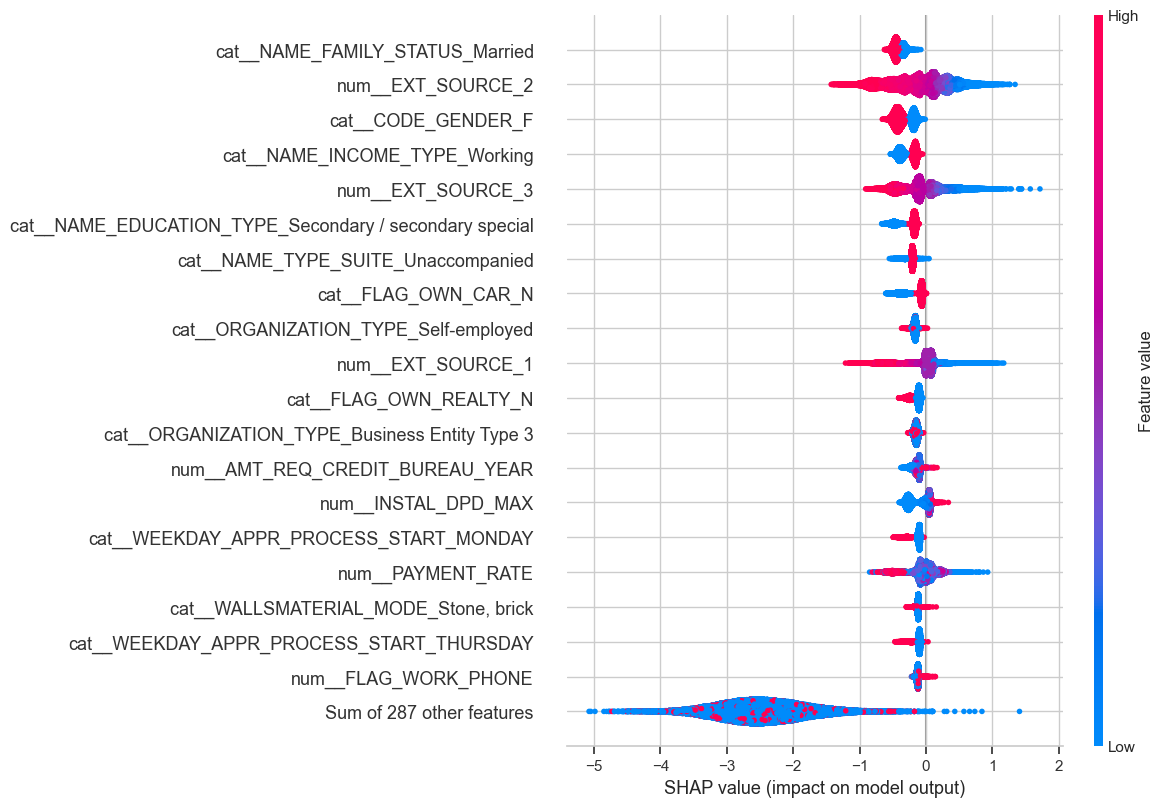

In [173]:
# on récupère le modèle avec l'alias CHAMPION_ALIAS

model_uri = "models:/credit_score_reg_model@champion"
best_pipe = mlflow.sklearn.load_model(model_uri)

preprocess = best_pipe.named_steps["preprocess"]
model = best_pipe.named_steps["model"]


# échantillon pour SHAP
X_sample = X_test.sample(1000, random_state=42)
# X_sample = X_test.sample(1000, random_state=42)

# transformation comme à l'entraînement
X_transformed = preprocess.transform(X_test)
# X_transformed = preprocess.transform(X_sample)

# récupération des noms après OHE / scaling
feature_names = preprocess.get_feature_names_out()

# conversion en DataFrame pour intégrer les noms
X_shap = pd.DataFrame(
    X_transformed.toarray() if hasattr(X_transformed, "toarray") else X_transformed,
    columns=feature_names
)

explainer = shap.TreeExplainer(
    model,
    feature_perturbation="tree_path_dependent"
)
shap_values = explainer(X_shap)

shap.plots.beeswarm(shap_values, max_display=20)

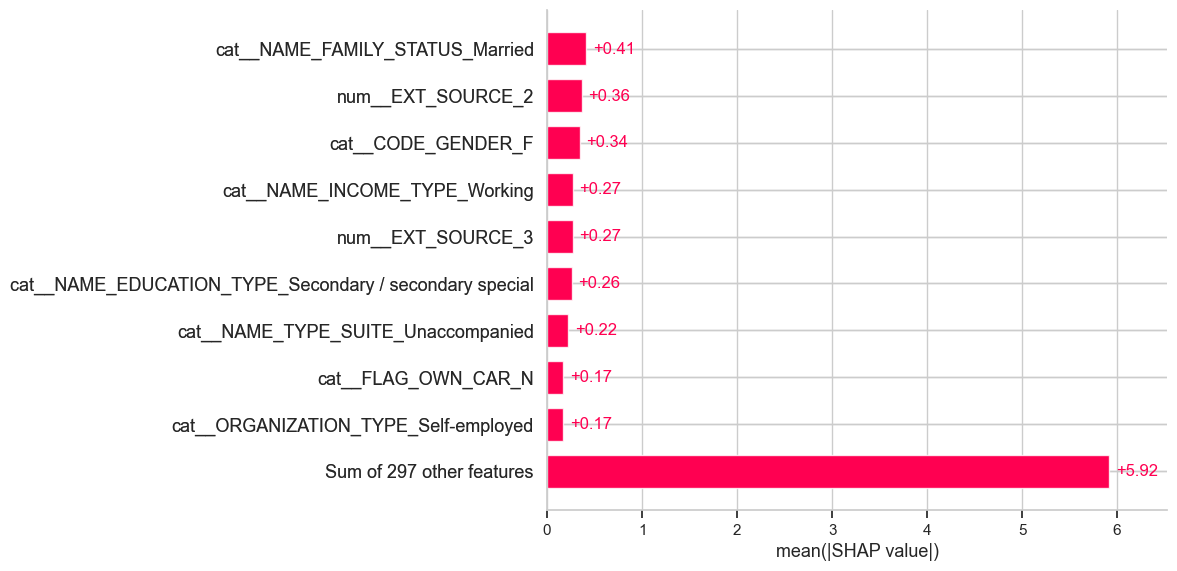

In [174]:
shap.plots.bar(shap_values)

## Locale

In [175]:
preds = best_pipe.predict(X_test)

idx_0 = np.where(preds == 0)[0][0]
idx_1 = np.where(preds == 1)[0][0]

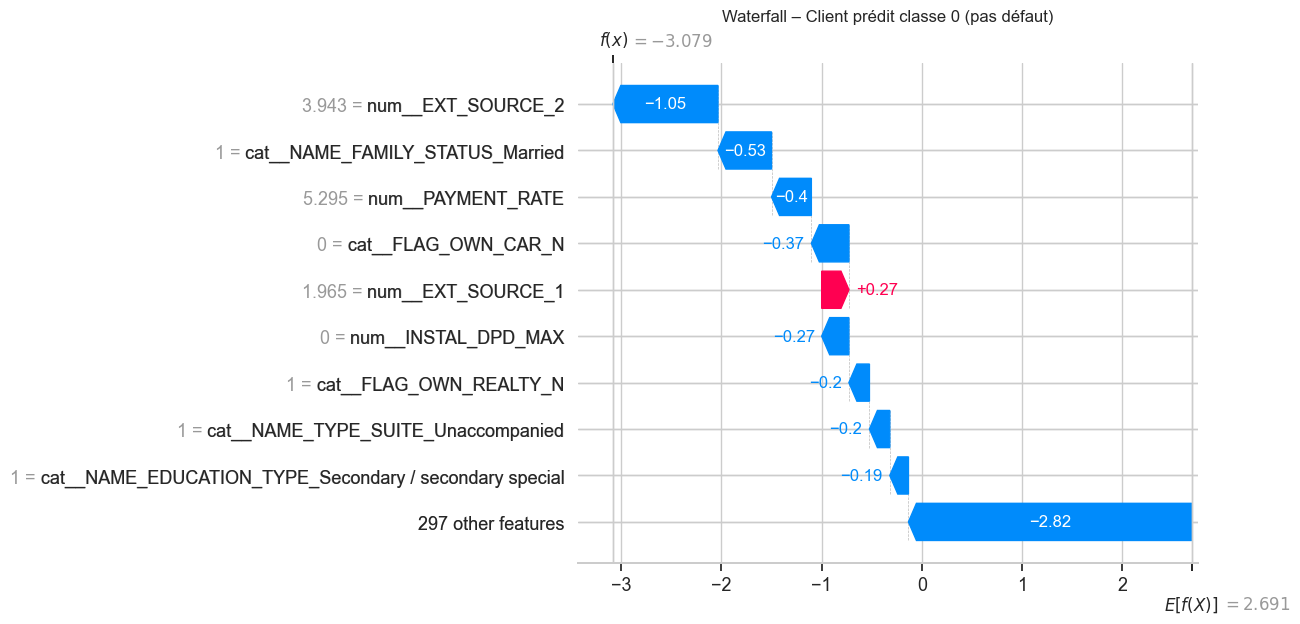

In [176]:
plt.figure()
shap.plots.waterfall(shap_values[idx_0], show=False)
plt.title("Waterfall – Client prédit classe 0 (pas défaut)")
plt.show()

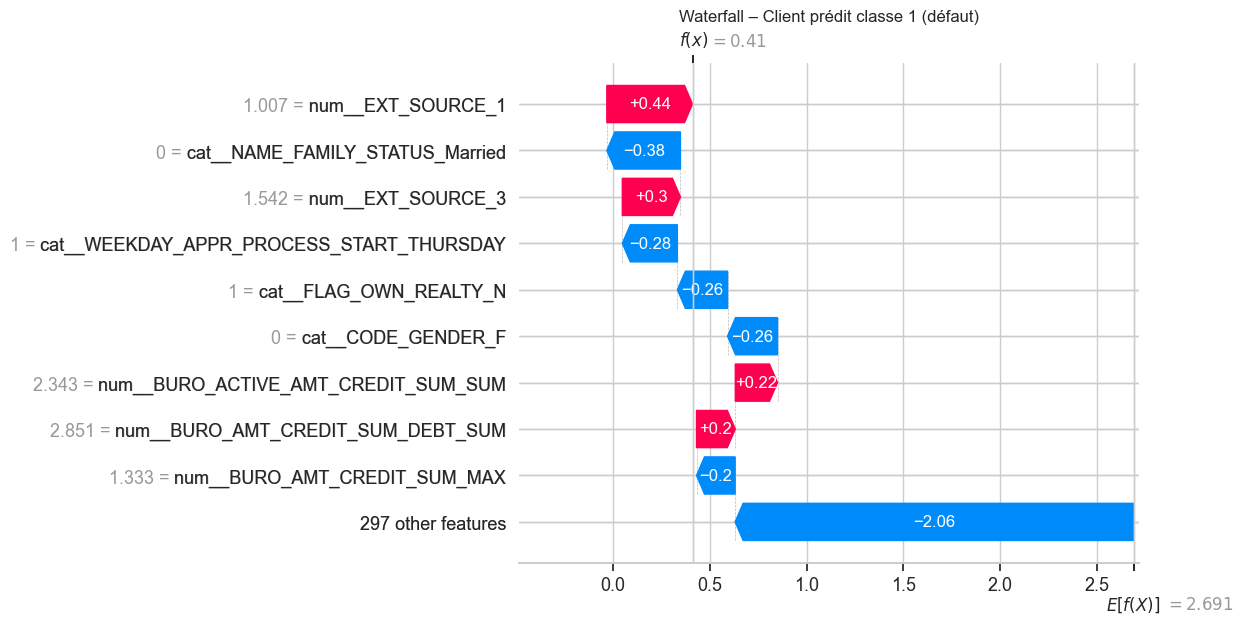

In [177]:
plt.figure()
shap.plots.waterfall(shap_values[idx_1], show=False)
plt.title("Waterfall – Client prédit classe 1 (défaut)")
plt.show()

# Data Drift

In [ ]:
##### Préparation des données #####
train_df = pd.read_csv("data/raw/application_train.csv")
test_df = pd.read_csv("data/raw/application_test.csv")

# suppression des colonnes non pertinentes pour l'évaluation du data drift
train_df = train_df.drop(columns=["TARGET","SK_ID_CURR"])
test_df = test_df.drop(columns=["SK_ID_CURR"])

# Aligner strictement les colonnes
common_cols = sorted(set(train_df.columns).intersection(test_df.columns))
train_df = train_df[common_cols]
test_df = test_df[common_cols]

##### Génération du rapport #####
report = Report([DataDriftPreset()], include_tests=True)
my_eval = report.run(current_data=test_df, reference_data=train_df)
my_eval.save_html("data_drift_report.html")

my_eval